# Dimensionality Reduction

In [3]:
import numpy as np
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt

In [4]:
data_dir = './data/ORL/'

images = []
labels = []

for subject in sorted(os.listdir(data_dir)):
    subject_path = os.path.join(data_dir, subject)
    if not os.path.isdir(subject_path):
        continue
    
    label = int(subject[1:]) # s1 -> 1
    for file in sorted(os.listdir(subject_path)):
        if file.endswith("pgm"):
            img = Image.open(os.path.join(subject_path, file))
            images.append(np.array(img, dtype=np.float64).flatten())
            labels.append(label)
            
X = np.array(images)          # shape (400, 10304)
y = np.array(labels)          # shape (400,)
X.shape, y.shape
 

((400, 10304), (400,))

We've flatten the Images with numpy => $X∈R 400×10304$

In [5]:
mean_face = X.mean(axis=0)
X_centered = X - mean_face
X_centered

array([[-37.6175, -36.5775, -40.925 , ..., -29.87  , -29.865 , -29.2275],
       [-51.6175, -51.5775, -52.925 , ..., -39.87  , -35.865 , -42.2275],
       [-25.6175, -25.5775, -23.925 , ..., -44.87  , -41.865 , -41.2275],
       ...,
       [ 26.3825,  23.4225,  30.075 , ...,  16.13  ,  12.135 ,  16.7725],
       [ 25.3825,  28.4225,  26.075 , ...,  11.13  ,  10.135 ,  16.7725],
       [ 24.3825,  26.4225,  27.075 , ...,  15.13  ,  11.135 ,  14.7725]],
      shape=(400, 10304))

- PCA assumes zero-mean data
- Eigenvectors of covariance depend on centering

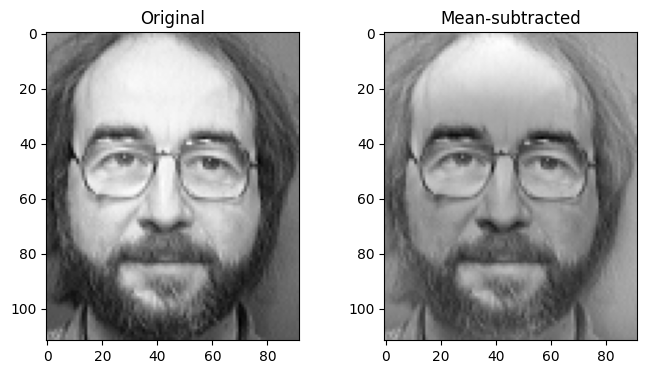

In [17]:
# Let's see the Mean-Subtracted Image next to the original!
idx = np.random.randint(0, len(X))
original = X[idx].reshape(112, 92)
centered = X_centered[idx].reshape(112, 92)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(original, cmap="gray")

plt.subplot(1,2,2)
plt.title("Mean-subtracted")
plt.imshow(centered, cmap="gray")
plt.show()


#### Optional normalization (unit variance)

* Unit variance emphasizes fine details

* May amplify noise

* PCA is sensitive to scaling

In [18]:
std = X_centered.std(axis=0) + 1e-8
X_normalized = X_centered / std
X_normalized

array([[-1.05125993, -1.02502268, -1.15078496, ..., -0.63687931,
        -0.67224364, -0.66490378],
       [-1.4425044 , -1.44537235, -1.48821733, ..., -0.85009635,
        -0.80730013, -0.96064407],
       [-0.71590752, -0.71676625, -0.67275578, ..., -0.95670487,
        -0.94235661, -0.93789481],
       ...,
       [ 0.73728624,  0.65637601,  0.84568986, ...,  0.34391909,
         0.27315174,  0.38156184],
       [ 0.7093402 ,  0.79649257,  0.73321241, ...,  0.23731057,
         0.22813291,  0.38156184],
       [ 0.68139417,  0.74044595,  0.76133177, ...,  0.32259739,
         0.25064232,  0.33606334]], shape=(400, 10304))

--- 

### Principal Component Analysis (PCA)


PCA finds orthogonal directions:

$w1​,w2​,…$

_that maximize variance, without using class labels._

It answers:

“Along which directions does the data vary the most?”

""PCA Defined as an orthogonal linear transformation that transforms the data to a new coordinate system
such that the **greatest variance** by some scaler projection of the data comes to lie on the first coordinate (The First Principle Component)""

---

### Eiguen decomposition (efficient PCA)

In [19]:
N = X_centered.shape[0]

# Small covariance
C_small = (X_centered @ X_centered.T) / N
eigvals, eigvecs_small = np.linalg.eigh(C_small)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs_small = eigvecs_small[:, idx]

# Map to eigenfaces
eigfaces = X_centered.T @ eigvecs_small
eigfaces = eigfaces / np.linalg.norm(eigfaces, axis=0)


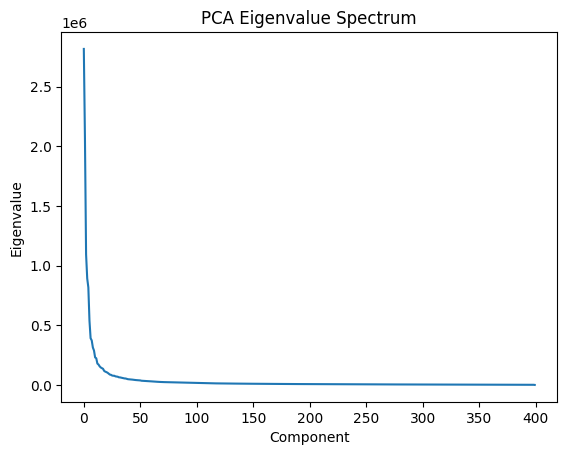

In [20]:
plt.plot(eigvals)
plt.title("PCA Eigenvalue Spectrum")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()


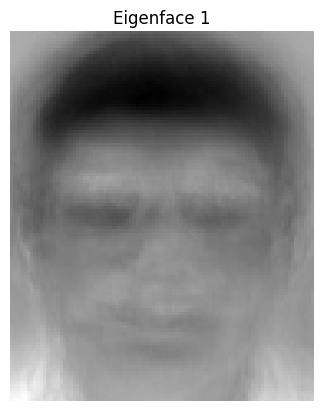

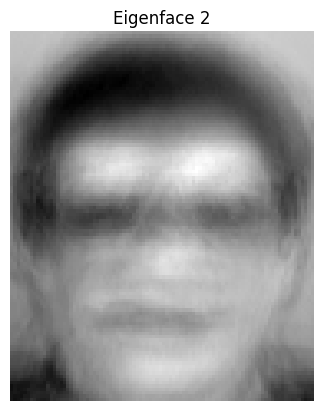

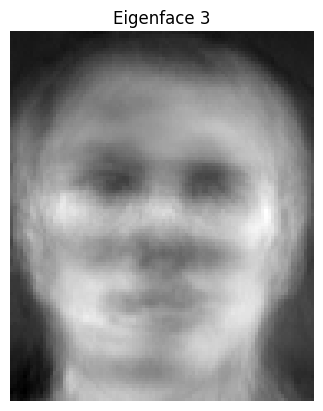

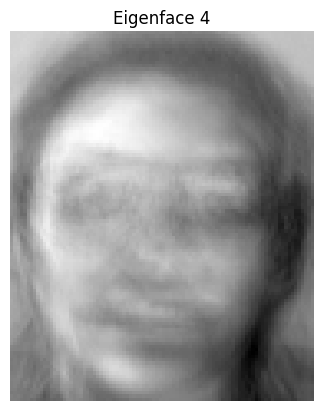

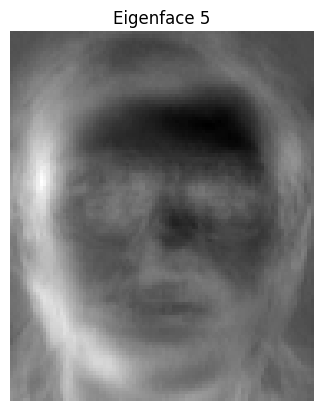

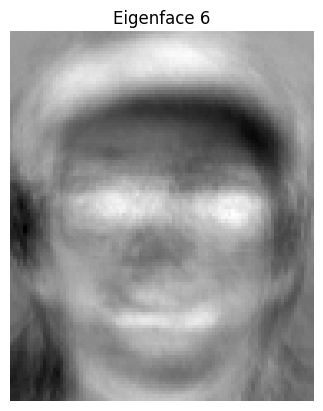

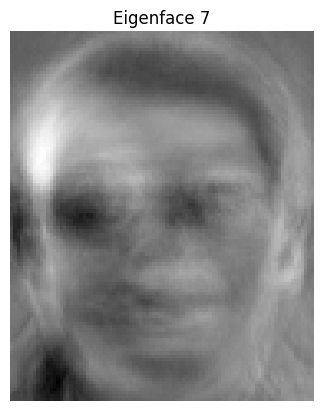

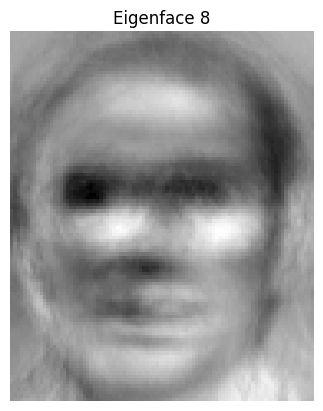

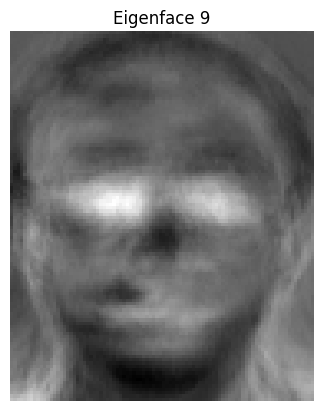

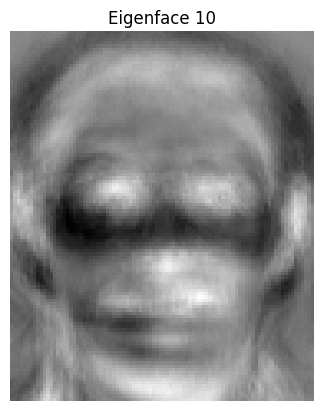

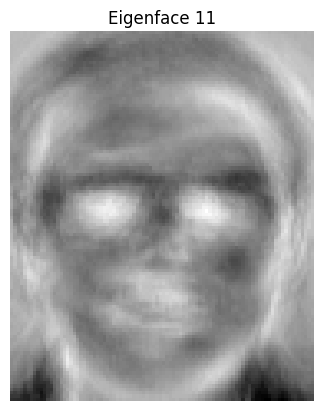

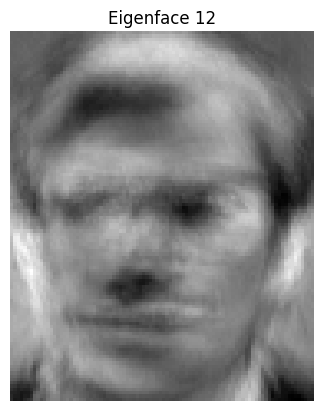

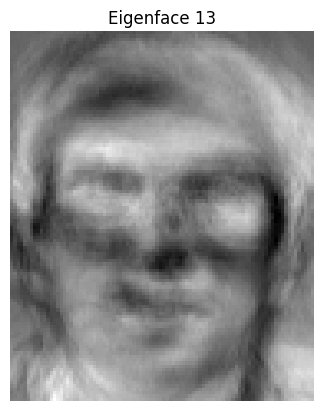

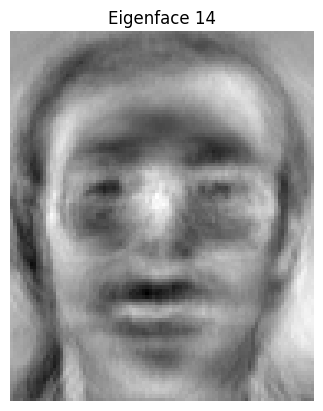

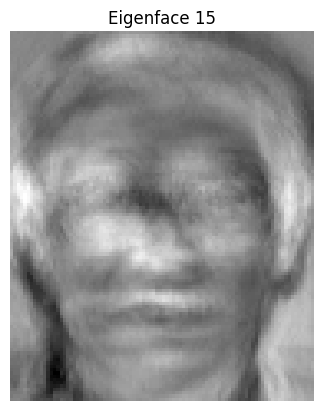

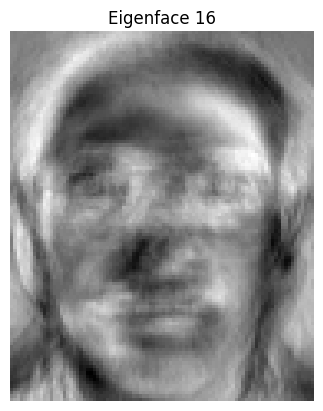

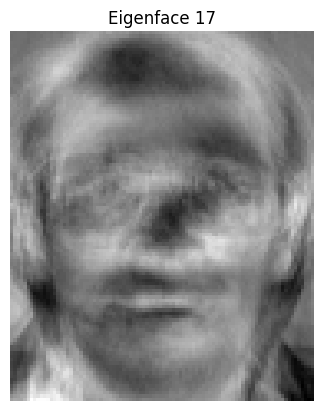

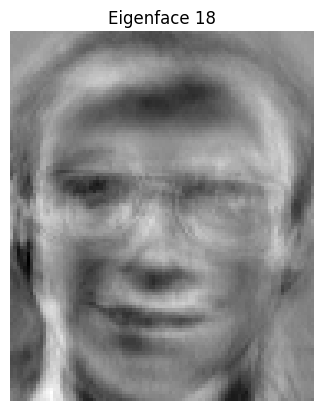

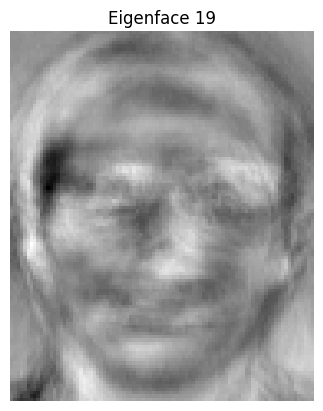

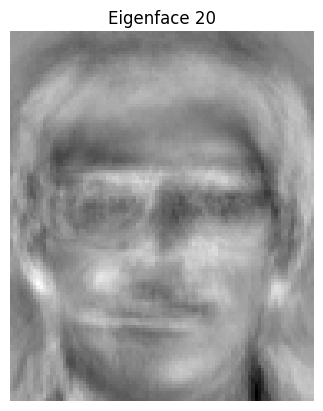

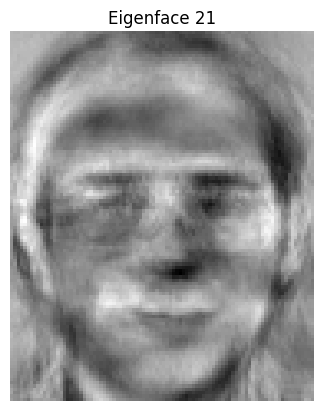

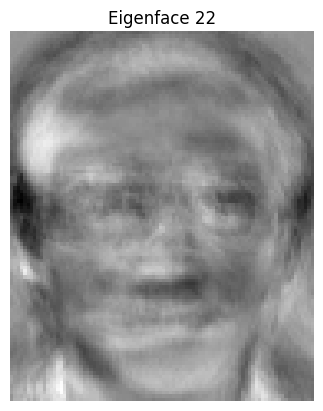

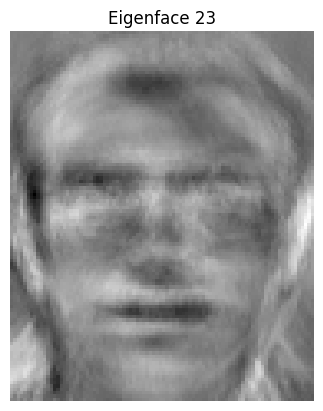

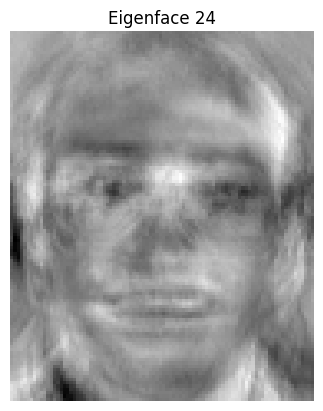

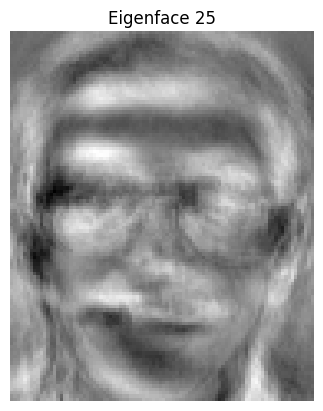

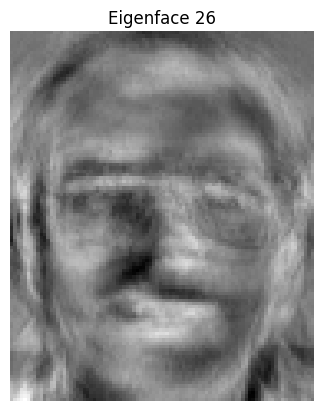

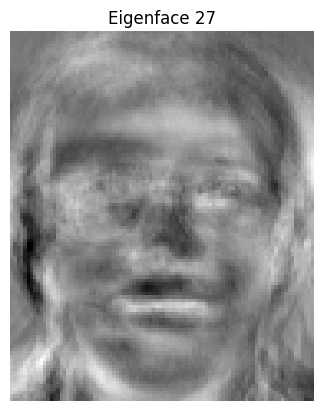

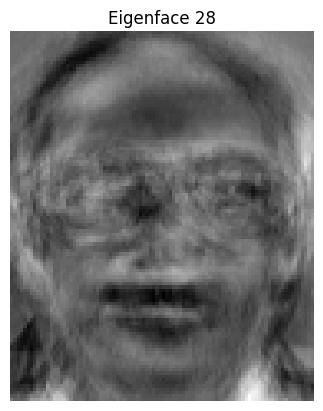

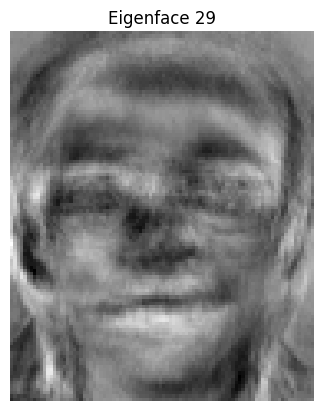

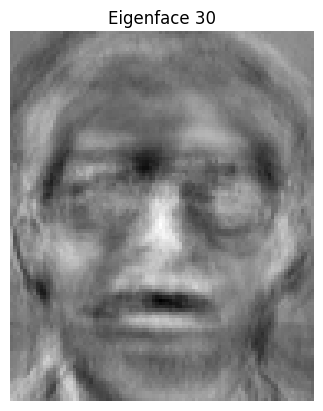

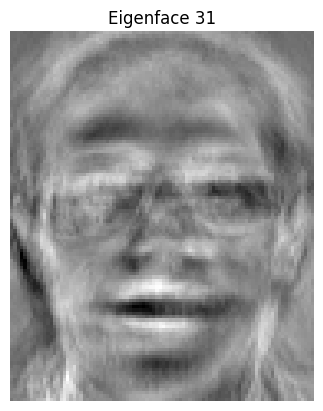

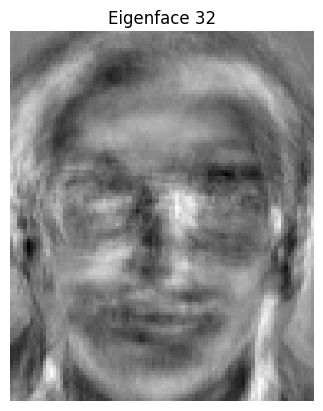

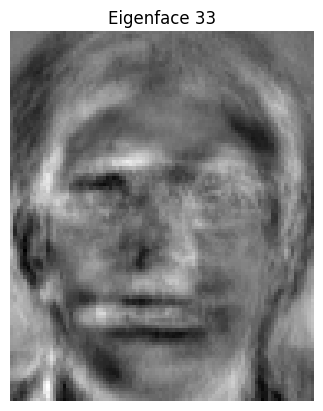

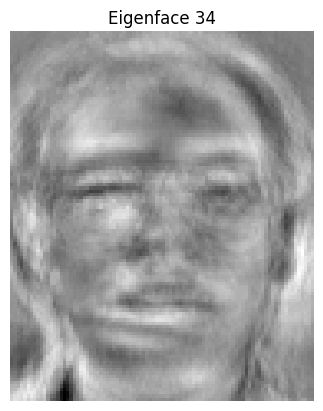

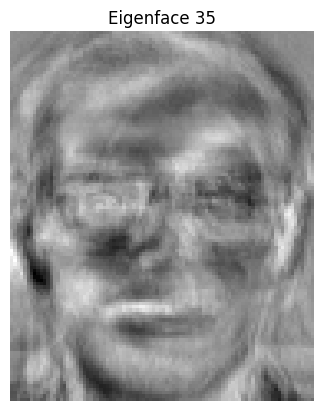

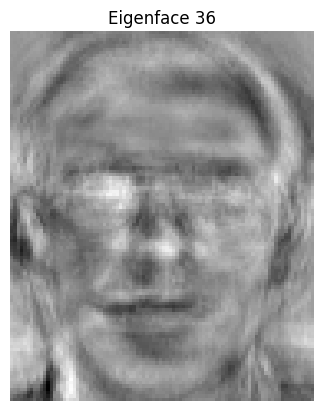

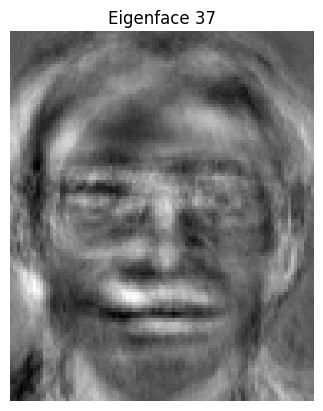

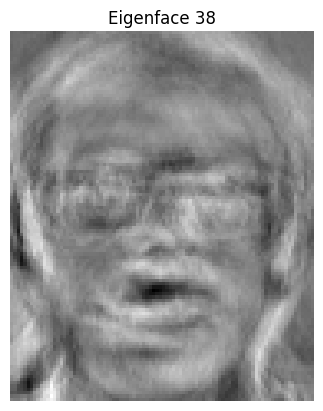

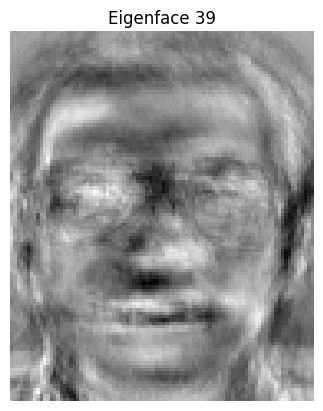

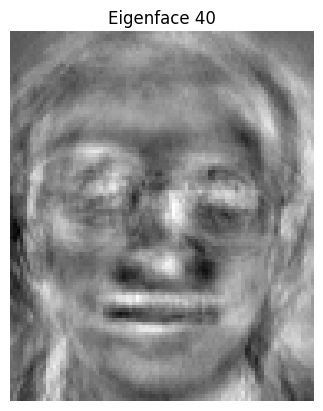

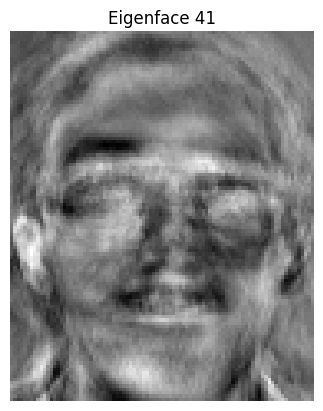

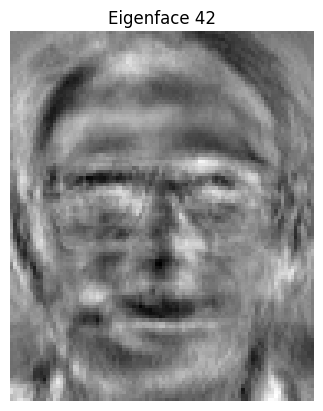

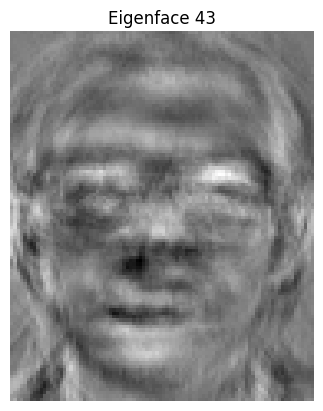

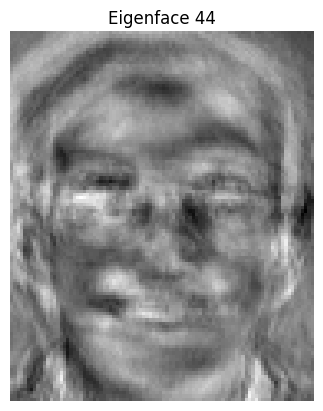

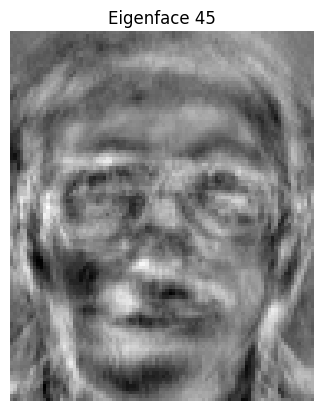

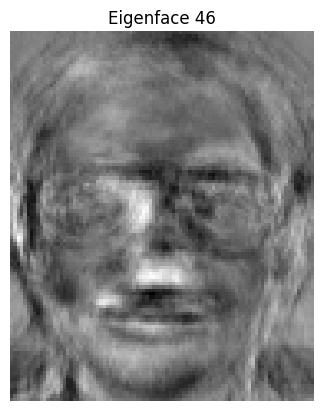

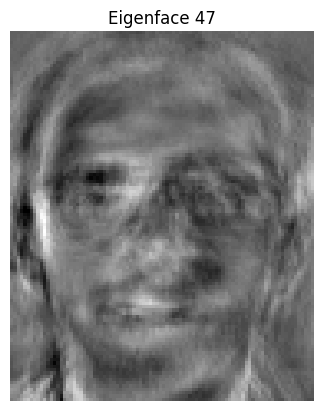

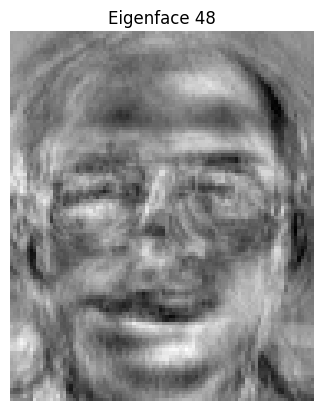

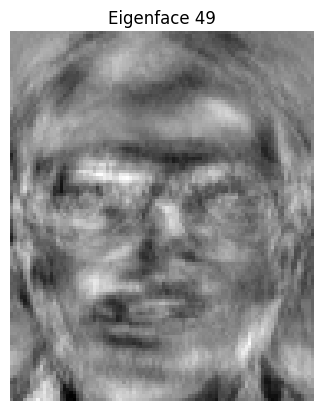

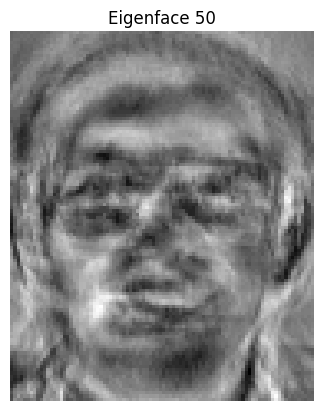

In [21]:
# Top 50 Eigen Faces
for i in range(50):
    plt.figure()
    plt.imshow(eigfaces[:, i].reshape(112, 92), cmap="gray")
    plt.title(f"Eigenface {i+1}")
    plt.axis("off")
    plt.show()


In [22]:
# projection
k = 50
W = eigfaces[:, :k]

X_pca = X_centered @ W

# Reconstruction 
X_recon = X_pca @ W.T + mean_face

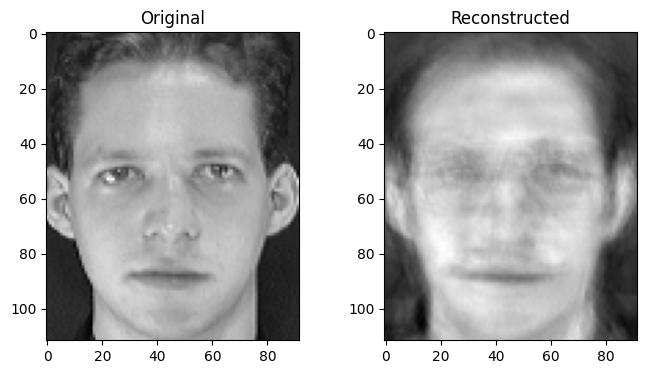

In [23]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(X[0].reshape(112,92), cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(X_recon[0].reshape(112,92), cmap="gray")
plt.title("Reconstructed")
plt.show()


In [24]:
cum_var = np.cumsum(eigvals) / np.sum(eigvals)
num_90 = np.argmax(cum_var >= 0.9) + 1
print(num_90)

111


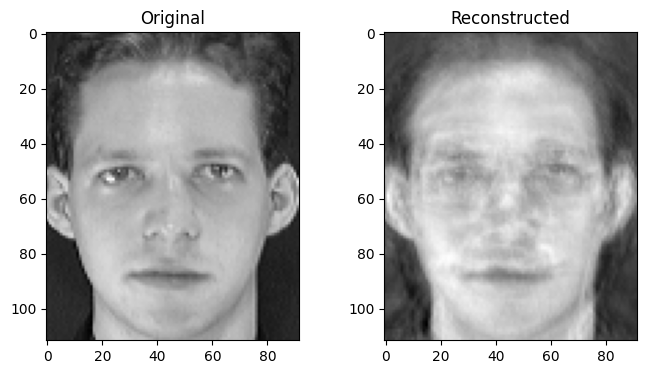

In [25]:
# projection
k = 111
W = eigfaces[:, :k]

X_pca = X_centered @ W

# Reconstruction 
X_recon = X_pca @ W.T + mean_face


plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(X[0].reshape(112,92), cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(X_recon[0].reshape(112,92), cmap="gray")
plt.title("Reconstructed")
plt.show()


#### Why PCA alone is not optimal

- PCA ignores class labels

- Directions of maximum variance ≠ maximum separability

---

ORL has 10 images per person.
Leave-one-out per individual means:

For each subject:

- 1 image → test

- Remaining 9 → train

Total:

- Train = 360 images

- Test = 40 images

In [26]:
def leave_one_out(X, y):
    train_idx = []
    test_idx = []

    for c in np.unique(y):
        idx = np.where(y == c)[0]
        test = np.random.choice(idx)
        train = np.setdiff1d(idx, test)

        train_idx.extend(train)
        test_idx.append(test)

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


In [27]:
# Split
X_train, y_train, X_test, y_test = leave_one_out(X, y)

# Center using training mean ONLY
mu_train = X_train.mean(axis=0)
X_train_c = X_train - mu_train
X_test_c  = X_test  - mu_train

# Project to PCA space
X_train_pca = X_train_c @ W
X_test_pca  = X_test_c  @ W


In [28]:
X_train, y_train, X_test, y_test = leave_one_out(X, y)

mean_face = X_train.mean(axis=0)

Xtr_c = X_train - mean_face
Xte_c = X_test - mean_face

# PCA
N = Xtr_c.shape[0]
C_small = (Xtr_c @ Xtr_c.T) / N + 1
eigvals, eigvecs = np.linalg.eigh(C_small)

idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]

# Eigenfaces
eigfaces = Xtr_c.T @ eigvecs
eigfaces /= np.linalg.norm(eigfaces, axis=0)


In [29]:
k = 50  # example
W = eigfaces[:, :k]

Z_train = Xtr_c @ W   # (360 × k)
Z_test  = Xte_c @ W   # (40 × k)


#### LDA (Linear Discriminant Analysis)

* Each class has:

  * Mean ( $\mu_c$ )
* All classes share:

  * Same covariance ( $\Sigma$ )

Decision rule:
$
\arg\max_c ; z^T \Sigma^{-1}\mu_c - \frac{1}{2}\mu_c^T\Sigma^{-1}\mu_c
$

In [30]:
def train_lda(X, y):
    classes = np.unique(y)
    means = {}
    cov = np.zeros((X.shape[1], X.shape[1]))

    for c in classes:
        Xc = X[y == c]
        mu_c = Xc.mean(axis=0)
        means[c] = mu_c
        cov += (Xc - mu_c).T @ (Xc - mu_c)

    cov /= (len(X) - len(classes))
    cov_inv = np.linalg.pinv(cov)

    return means, cov_inv

def predict_lda(X, means, cov_inv):
    preds = []
    for x in X:
        scores = {}
        for c, mu in means.items():
            scores[c] = x @ cov_inv @ mu - 0.5 * mu @ cov_inv @ mu
        preds.append(max(scores, key=scores.get))
    return np.array(preds)


#### QDA (Quadratic Discriminant Analysis)

* Each class has:

  * Its **own covariance**
* More flexible but needs more data

Decision rule:
$
-\frac{1}{2}\log|\Sigma_c|
-\frac{1}{2}(z-\mu_c)^T\Sigma_c^{-1}(z-\mu_c)
$

In [31]:
def train_qda(X, y):
    classes = np.unique(y)
    models = {}

    for c in classes:
        Xc = X[y == c]
        mu = Xc.mean(axis=0)
        cov = np.cov(Xc, rowvar=False) + 1e-6 * np.eye(X.shape[1])
        models[c] = (mu, np.linalg.inv(cov), np.linalg.det(cov))

    return models

def predict_qda(X, models):
    preds = []
    for x in X:
        scores = {}
        for c, (mu, cov_inv, det) in models.items():
            diff = x - mu
            scores[c] = -0.5 * np.log(det) - 0.5 * diff @ cov_inv @ diff
        preds.append(max(scores, key=scores.get))
    return np.array(preds)

In [32]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [33]:
lda_means, lda_cov_inv = train_lda(X_train_pca, y_train)
y_pred_lda = predict_lda(X_test_pca, lda_means, lda_cov_inv)

qda_models = train_qda(X_train_pca, y_train)
y_pred_qda = predict_qda(X_test_pca, qda_models)

print("LDA Accuracy:", accuracy(y_test, y_pred_lda))
print("QDA Accuracy:", accuracy(y_test, y_pred_qda))


LDA Accuracy: 1.0
QDA Accuracy: 0.025


/Users/parsabordbar/venev/ml/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2430: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/parsabordbar/venev/ml/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2430: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/parsabordbar/venev/ml/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2430: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/var/folders/n4/fny8874j7nb_j4kw7vcpdm_00000gn/T/ipykernel_54995/742492894.py:19: RuntimeWarning: divide by zero encountered in log
  scores[c] = -0.5 * np.log(det) - 0.5 * diff @ cov_inv @ diff


In [34]:
ks = range(10, 151, 10)
lda_acc, qda_acc = [], []

for k in ks:
    Wk = eigfaces[:, :k]

    Xtr_pca = (X_train - mu_train) @ Wk
    Xte_pca = (X_test  - mu_train) @ Wk

    lda_means, lda_cov = train_lda(Xtr_pca, y_train)
    lda_acc.append(accuracy(y_test, predict_lda(Xte_pca, lda_means, lda_cov)))

    qda_models = train_qda(Xtr_pca, y_train)
    qda_acc.append(accuracy(y_test, predict_qda(Xte_pca, qda_models)))


/var/folders/n4/fny8874j7nb_j4kw7vcpdm_00000gn/T/ipykernel_54995/742492894.py:19: RuntimeWarning: divide by zero encountered in log
  scores[c] = -0.5 * np.log(det) - 0.5 * diff @ cov_inv @ diff


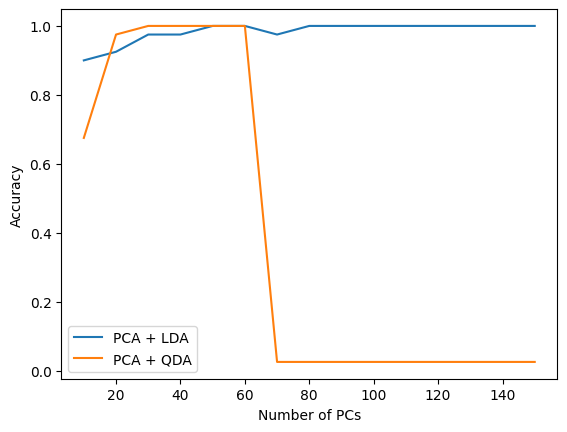

In [35]:
plt.plot(ks, lda_acc, label="PCA + LDA")
plt.plot(ks, qda_acc, label="PCA + QDA")
plt.xlabel("Number of PCs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

- Small k → underfitting (lost discriminative info)

- Large k → overfitting (noise, covariance instability)

- Optimal k balances bias–variance

In [36]:
def predict_nn(X_train, y_train, X_test):
    preds = []
    for x in X_test:
        dists = np.linalg.norm(X_train - x, axis=1)
        preds.append(y_train[np.argmin(dists)])
    return np.array(preds)

y_pred_nn = predict_nn(X_train_pca, y_train, X_test_pca)
print("PCA + NN Accuracy:", accuracy(y_test, y_pred_nn))

PCA + NN Accuracy: 0.95


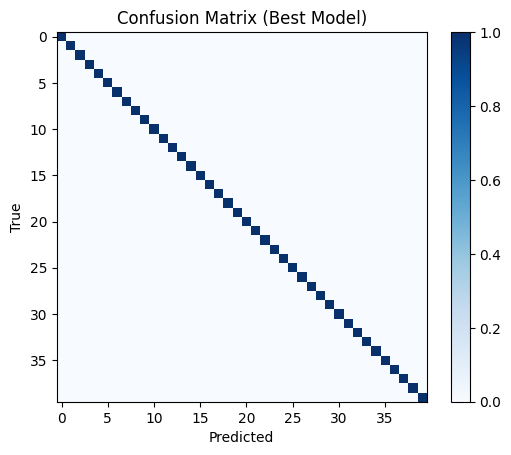

In [37]:
def confusion_matrix(y_true, y_pred):
    classes = np.unique(y_true)
    cm = np.zeros((len(classes), len(classes)), dtype=int)

    for i, c1 in enumerate(classes):
        for j, c2 in enumerate(classes):
            cm[i, j] = np.sum((y_true == c1) & (y_pred == c2))
    return cm

cm = confusion_matrix(y_test, y_pred_lda)
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Fisher Linear Discriminant Analysis (Fisher LDA)

$J(w) =
\frac{w^T S_B w}{w^T S_W w}$

--- 

#### Whitening

Whitening decorrelates features:

$X \leftarrow \Sigma^{-1/2} X$

_Is it essential?_

- No, mathematically redundant

- Fisher criterion already handles covariance

- Can improve numerical conditioning

---

Scatter Matrices

### Definitions

Let:

* $\mu$ : global mean
* $\mu_c$ : class mean

#### Within-class scatter

$S_W = \sum_c \sum_{x \in c} (x - \mu_c)(x - \mu_c)^T$

#### Between-class scatter

$S_B = \sum_c N_c (\mu_c - \mu)(\mu_c - \mu)^T$


---

In [38]:
classes = np.unique(y)
mu = X.mean(axis=0)

SW = np.zeros((X.shape[1], X.shape[1]))
SB = np.zeros_like(SW)

for c in classes:
    Xc = X[y == c]
    mu_c = Xc.mean(axis=0)

    SW += (Xc - mu_c).T @ (Xc - mu_c)
    diff = (mu_c - mu).reshape(-1,1)
    SB += len(Xc) * (diff @ diff.T)


In [39]:
# Assume X_pca is output of PCA projection (N x k)
mu = X_pca.mean(axis=0)
Xc = X_pca - mu


#### whitening

Whitening transforms data so that:


$\text{Cov}(X_{white}) = I$

* Features are **uncorrelated**
* All variances = 1


Given covariance:
$
\Sigma = U \Lambda U^T
$

Whitening transform:
$
X_{white} = X U \Lambda^{-1/2}
$

In [40]:
cov = np.cov(Xc, rowvar=False)

# Eigen-decomposition
eigvals, eigvecs = np.linalg.eigh(cov)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Whitening transform
W_white = eigvecs @ np.diag(1.0 / np.sqrt(eigvals + 1e-8))
X_white = Xc @ W_white


In [42]:
# Check If the Whitening worked 
np.round(np.cov(X_white, rowvar=False), 2)


array([[ 1., -0., -0., ...,  0., -0.,  0.],
       [-0.,  1.,  0., ..., -0., -0.,  0.],
       [-0.,  0.,  1., ...,  0.,  0., -0.],
       ...,
       [ 0., -0.,  0., ...,  1.,  0.,  0.],
       [-0., -0.,  0., ...,  0.,  1., -0.],
       [ 0.,  0., -0., ...,  0., -0.,  1.]], shape=(111, 111))

#### _Is Whitening Esential for Fisher LDA?_

Fisher LDA finds directions that maximize:

$
J(w) = \frac{w^T S_B w}{w^T S_W w}
$

This leads to solving:

$
S_B w = \lambda S_W w
$

or equivalently:

$
w = \text{eig}(S_W^{-1} S_B)
$

* Whitening transforms **both** ( $S_W$ ) and ( $S_B$ )
* The generalized eigenvalue problem remains **equivalent up to linear transform**

Thus:

Whitening **does not change the discriminative subspace**, only its coordinate representation.

---

#### _When whitening is useful (but not required)?_


**Can be Helpful when:**
* ( S_W ) is ill-conditioned or nearly singular
* Feature scales differ drastically
* Numerical stability is a concern

**Not needed when:**
* PCA already reduced dimensionality
* ( S_W ) is invertible
* Dataset is well-conditioned (like ORL after PCA)

---

| Method     | Goal                   | Whitening needed? |
| ---------- | ---------------------- | ----------------- |
| PCA        | Maximize variance      | Optional          |
| PCA + LDA  | Maximize separability  | No                |
| Fisher LDA | Uses ( S_W^{-1} )      | No                |
| QDA        | Uses class covariances | Sometimes         |


### Between-Class Scatter (SB) and Within-Class Scatter (SW)


* Within-class scatter ( S_W )
  → how much faces of the **same person vary**

* Between-class scatter ( S_B )
  → how far **different people’s mean faces** are from each other


In [43]:
classes = np.unique(y)
mu = X_pca.mean(axis=0)      # global mean (k,)

In [44]:
# Initialization of scatter matrices
k = X_pca.shape[1]
SW = np.zeros((k, k))
SB = np.zeros((k, k))

In [45]:
for c in classes:
    Xc = X_pca[y == c]              # samples of class c
    mu_c = Xc.mean(axis=0)
    Nc = Xc.shape[0]                # samples per class (ORL: 10)

    # Within-class scatter
    Xc_centered = Xc - mu_c
    SW += Xc_centered.T @ Xc_centered

    # Between-class scatter
    diff = (mu_c - mu).reshape(-1, 1)
    SB += Nc * (diff @ diff.T)

#### within-class vs between-class scatter (ORL-specific)

##### Within-class scatter ( S_W )

$
S_W = \sum_c \sum_{x \in c} (x - \mu_c)(x - \mu_c)^T
$

**In ORL terms:**

* Same person
* Different lighting
* Slight pose changes
* Facial expression differences

➡ Measures **intra-person variability**

Large ( S_W ) ⇒ same person looks inconsistent

---

##### Between-class scatter ( S_B )

$
S_B = \sum_c N_c (\mu_c - \mu)(\mu_c - \mu)^T
$

**In ORL terms:**

* Differences between *average faces* of different people
* Captures identity-related structure

Large ( S_B ) ⇒ identities are well-separated



| Matrix  | Measures                     | ORL meaning                            |
| ------- | ---------------------------- | -------------------------------------- |
| ( S_W ) | Variation *within* classes   | Same person under different conditions |
| ( S_B ) | Separation *between* classes | Different people                       |


---

## 2.3.2-3 Effect of class size & distribution

### Class size (ORL is balanced)

* ORL: **40 classes × 10 images**
* Balanced ⇒ each class contributes equally to ( S_B )
* No class dominates scatter

If classes were imbalanced:

* Large classes dominate ( S_W )
* Bias in discriminant directions

---

### Class distribution (tight vs spread)

* **Tight classes**
  → small ( S_W )
  → easy classification

* **Overlapping classes**
  → large ( S_W )
  → LDA struggles

---

### ORL implication

ORL is:

* Moderately separable
* Moderate intra-class variation
* Well-suited for Fisher LDA *after PCA*
---

#### 2.3.3 Eigenvalue Problem for LDA


**Fisher criterion**

$
J(w) = \frac{w^T S_B w}{w^T S_W w}
$

Maximizing this leads to:

$
S_B w = \lambda S_W w
$

Equivalent to:

$
S_W^{-1} S_B w = \lambda w
$

---

In [46]:
# Regularize SW for numerical stability
SW_reg = SW + 1e-6 * np.eye(SW.shape[0])

# Solve eigenproblem
eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(SW_reg) @ SB)

# Keep real part (numerical safety)
eigvals = eigvals.real
eigvecs = eigvecs.real

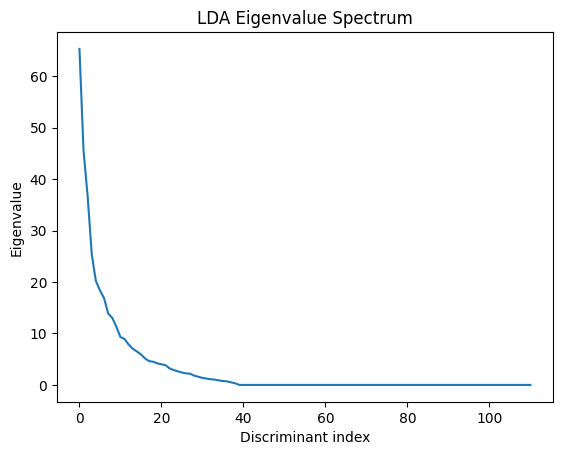

In [47]:
idx = np.argsort(eigvals)[::-1]
eigvals_sorted = eigvals[idx]

plt.plot(eigvals_sorted)
plt.xlabel("Discriminant index")
plt.ylabel("Eigenvalue")
plt.title("LDA Eigenvalue Spectrum")
plt.show()

##### 2.3.3-3 Why descending order?

**Larger** eigenvalues correspond to directions that **maximize** the ratio of between-class variance to within-class variance.


_Meaning of ordering_

* Largest eigenvalue → best class separation

* Small eigenvalues → noisy or non-discriminative directions

LDA keeps:
$
\min(C - 1, k)
$
discriminants


For ORL:
$
C = 40 \Rightarrow \text{max 39 discriminants}
$

---

#### 2.3.3-4 Interpretation of eigenvalue magnitudes

**Interpretation table (VERY exam-friendly)**

| Eigenvalue size | Interpretation          |
| --------------- | ----------------------- |
| Large           | Strong class separation |
| Medium          | Partial discrimination  |
| Near zero       | No discriminative power |


**ORL-specific meaning**

* Top few eigenvalues → encode identity
* Later ones → lighting / expression noise
* Explains why LDA uses **few dimensions**

---


#### 2.3.4 Evaluating Separability


### What is a “separability metric”?

A **scalar measure** that quantifies how well classes are separated in a given subspace.

The **most standard Fisher separability metric** is:

$
J_k = \frac{\mathrm{tr}(W_k^T S_B W_k)}{\mathrm{tr}(W_k^T S_W W_k)}
$

Where:

* ( $W_k$ ) = first ( k ) LDA eigenvectors
* ( $\mathrm{tr}(\cdot)$ ) = trace (sum of diagonal elements)

---

**Why this metric?**

* Numerator → between-class spread
* Denominator → within-class spread
* Ratio directly matches Fisher’s objective

This is **textbook-correct**.

In [49]:
# LDA eigenvectors sorted by descending eigenvalues
W_lda = eigvecs[:, idx]

def separability_score(k, W, SW, SB):
    Wk = W[:, :k]
    num = np.trace(Wk.T @ SB @ Wk)
    den = np.trace(Wk.T @ SW @ Wk)
    return num / den

ks = range(1, min(40, W_lda.shape[1]) + 1)
scores = [separability_score(k, W_lda, SW, SB) for k in ks]


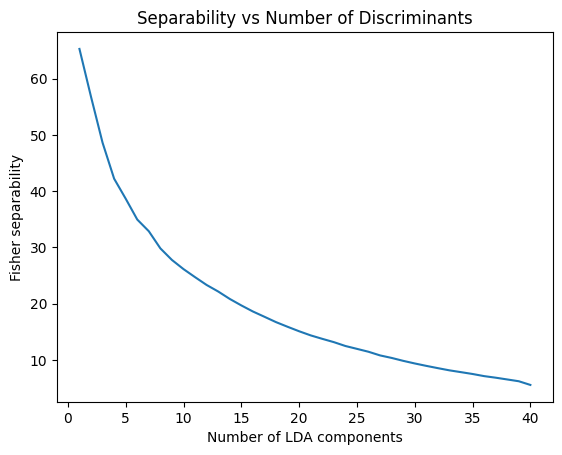

In [50]:
plt.plot(ks, scores)
plt.xlabel("Number of LDA components")
plt.ylabel("Fisher separability")
plt.title("Separability vs Number of Discriminants")
plt.show()

#### 2.3.4-2 Pitfalls: too few vs too many components

##### Too few components

* Insufficient discriminative directions
* Class means may overlap
* Underfitting

**In ORL terms**:

* Identity information lost
* Faces appear similar in projected space

---

##### Too many components

* Later LDA components correspond to:

  * Noise
  * Ill-conditioned scatter directions
* Overfitting
* Numerical instability

---

After a certain point, additional LDA components contribute marginal or no improvement in separability.

### 2.3.4-3 Decide optimal number of discriminants

#### How to choose ( k^* )?

Standard criteria:

1. **Elbow point** in separability curve
2. Point where improvement plateaus
3. Largest increase in score per added dimension

---

In [51]:
scores = np.array(scores)
delta = np.diff(scores)

k_opt = np.argmax(delta < 0.01) + 1
k_opt


np.int64(1)

### 2.3.4-4 Class-count constraint on discriminants

#### Fundamental LDA property

$
\text{rank}(S_B) \le C - 1
$

Where:

* ( C ) = number of classes

---

### For ORL

$
C = 40 \Rightarrow \max \text{ discriminants } = 39
$

Even if:

* Feature dimension = 10,000
* PCA dimension = 300

**LDA cannot exceed 39 meaningful directions.**

---

### Why?

* Only class means contribute to ( S_B )
* Only ( C ) mean vectors exist
* Centering removes one degree of freedom

---

### 2.3.4-5 Effect of class overlap & intra-class variability

#### High intra-class variability

* Increases ( S_W )
* Reduces separability ratio
* Forces fewer useful discriminants

**ORL causes:**

* Lighting variation
* Expression changes

---

#### Class overlap

* Means are close in feature space
* ( S_B ) small along many directions
* Eigenvalues decay faster

---

#### Consequence for component selection

> When classes overlap strongly, fewer LDA components are reliable, and selecting too many amplifies noise rather than discrimination.

---


| Question               | Answer                            |
| ---------------------- | --------------------------------- |
| Separability metric    | Fisher trace ratio                |
| Behavior vs components | Rapid rise then plateau           |
| Too few components     | Underfitting                      |
| Too many components    | Noise & instability               |
| Optimal number         | Elbow / marginal gain             |
| Max discriminants      | ( C-1 = 39 )                      |
| ORL-specific effect    | Moderate overlap → moderate ( k ) |

---


> **In Fisher LDA, discriminant components should be selected based on separability gain rather than dimensionality alone, with the theoretical maximum strictly limited by the number of classes.**



### 2.3.5 Projection into Lower-Dimensional Subspace

In [52]:
k = k_opt
Wk_lda = W_lda[:, :k]

X_lda = X_pca @ Wk_lda


**projection in LDA**

LDA finds a matrix ( W_{LDA} ) such that:

$
Z = X W_{LDA}
$

Where:

* ( $X \in \mathbb{R}^{N \times d}$ )
* ( $W_{LDA} \in \mathbb{R}^{d \times k}$ )
* ( $Z \in \mathbb{R}^{N \times k}$ )

### 2.3.5-2 Reasoning for selecting this number of dimensions

selected ( $k = k_{opt}$ ) because:

* Fisher separability **plateaus beyond this point**
* Additional components yield **negligible gains**
* Later discriminants correspond to:

  * Noise
  * Small eigenvalues
  * Poor class separation

Mathematically:

* Large LDA eigenvalues ⇒ high ( \frac{S_B}{S_W} )
* Small eigenvalues ⇒ low discriminative power

### 2.3.5-3 Trade-off: dimensionality vs information retention

#### Key trade-off

| Low dimensions        | High dimensions     |
| --------------------- | ------------------- |
| Compact               | More detailed       |
| Less noise            | Risk of overfitting |
| Faster classification | Higher variance     |

---

#### ORL-specific insight

* Identity is captured in **few discriminants**
* Lighting/expression dominate later ones
* Best recognition occurs **before full LDA rank**

---

### 2.3.6 Classification

In [54]:
def stratified_split(X, y, train_ratio=0.7):
    Xtr, Xte, ytr, yte = [], [], [], []

    for c in np.unique(y):
        idx = np.where(y == c)[0]
        np.random.shuffle(idx)

        split = int(len(idx) * train_ratio)
        train_idx, test_idx = idx[:split], idx[split:]

        Xtr.append(X[train_idx])
        Xte.append(X[test_idx])
        ytr.append(y[train_idx])
        yte.append(y[test_idx])

    return (np.vstack(Xtr), np.hstack(ytr),
            np.vstack(Xte), np.hstack(yte))

X_train, y_train, X_test, y_test = stratified_split(X_lda, y)


In [56]:
def train_gaussian_bayes(X, y):
    model = {}
    for c in np.unique(y):
        Xc = X[y == c]
        mu = Xc.mean(axis=0)
        cov = np.cov(Xc, rowvar=False) + 1e-6 * np.eye(X.shape[1])
        model[c] = (mu, np.linalg.inv(cov), np.linalg.det(cov))
    return model

def predict_gaussian_bayes(X, model):
    preds = []
    for x in X:
        scores = {}
        for c, (mu, cov_inv, det) in model.items():
            diff = x - mu
            scores[c] = -0.5 * np.log(det) - 0.5 * diff @ cov_inv @ diff
        preds.append(max(scores, key=scores.get))
    return np.array(preds)


#### 2.3.6-3 Effect of number of LDA components on accuracy

In [57]:
ks = range(1, min(39, W_lda.shape[1]) + 1)
accs = []

for k in ks:
    Xk = X_pca @ W_lda[:, :k]

    Xtr, ytr, Xte, yte = stratified_split(Xk, y)

    model = train_gaussian_bayes(Xtr, ytr)
    y_pred = predict_gaussian_bayes(Xte, model)

    accs.append(np.mean(y_pred == yte))


/Users/parsabordbar/venev/ml/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2430: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/parsabordbar/venev/ml/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2430: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/parsabordbar/venev/ml/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2430: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


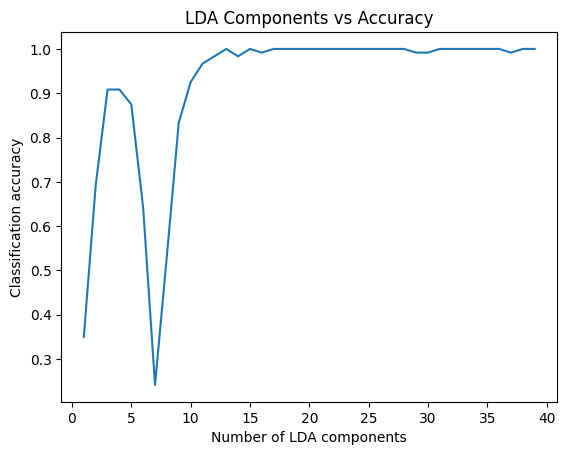

In [58]:
plt.plot(ks, accs)
plt.xlabel("Number of LDA components")
plt.ylabel("Classification accuracy")
plt.title("LDA Components vs Accuracy")
plt.show()

### 2.3.6-5 Which components matter most?

#### Observed behavior

* Accuracy rises quickly for first few components
* Plateaus after optimal ( k )
* Sometimes decreases due to overfitting

---

#### Interpretation

* Early components → high eigenvalues → strong separability
* Later components → noise-dominated
* Diminishing returns are expected


---

## 2.3.6-6 Theory vs practice discrepancies

#### Theoretical expectation

* Larger eigenvalues ⇒ better classification
* More components ⇒ more information

---

#### Practical reality

* Finite samples → covariance estimation noise
* Class overlap → limits discriminability
* Numerical instability in higher dimensions

---

#### ORL-specific conclusion

> Despite Fisher’s optimality criterion, real-world performance saturates early due to limited data and intra-class variation.
